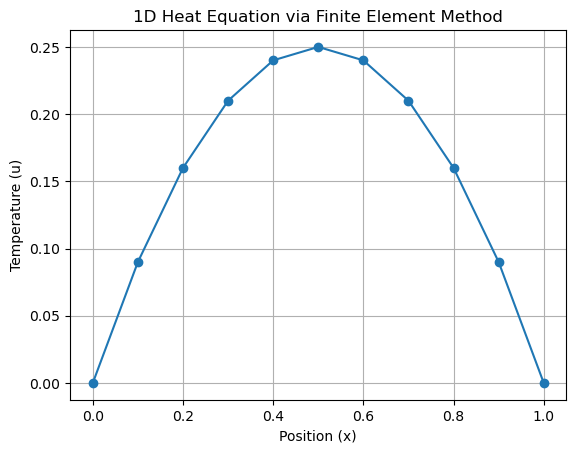

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters
L = 1.0           # Length of the rod
n_elements = 10   # Number of finite elements
n_nodes = n_elements + 1
h = L / n_elements  # Size of each element
f_value = 2.0     # Constant heat source term

# 2. Initialize Global Stiffness Matrix (K) and Load Vector (F)
K = np.zeros((n_nodes, n_nodes))
F = np.zeros(n_nodes)

# 3. Assembly Process (The "Heart" of FEA)
# We loop through each element and "stamp" its local stiffness into the global K
for i in range(n_elements):
    # Local stiffness for 1D Poisson: (1/h) * [[1, -1], [-1, 1]]
    K[i:i+2, i:i+2] += (1/h) * np.array([[1, -1], [-1, 1]])
    
    # Local load vector: (f*h/2) * [1, 1]
    F[i:i+2] += (f_value * h / 2) * np.array([1, 1])

# 4. Apply Boundary Conditions (u(0) = 0 and u(1) = 0)
# We "shrink" the system to solve only for internal nodes
K_internal = K[1:-1, 1:-1]
F_internal = F[1:-1]

# 5. Solve the Linear System (Ku = F)
u_internal = np.linalg.solve(K_internal, F_internal)

# Reconstruct full solution vector with boundary zeros
u = np.concatenate(([0], u_internal, [0]))
x = np.linspace(0, L, n_nodes)

# 6. Plotting
plt.plot(x, u, 'o-', label='FEA Solution')
plt.title("1D Heat Equation via Finite Element Method")
plt.xlabel("Position (x)")
plt.ylabel("Temperature (u)")
plt.grid(True)
plt.show()

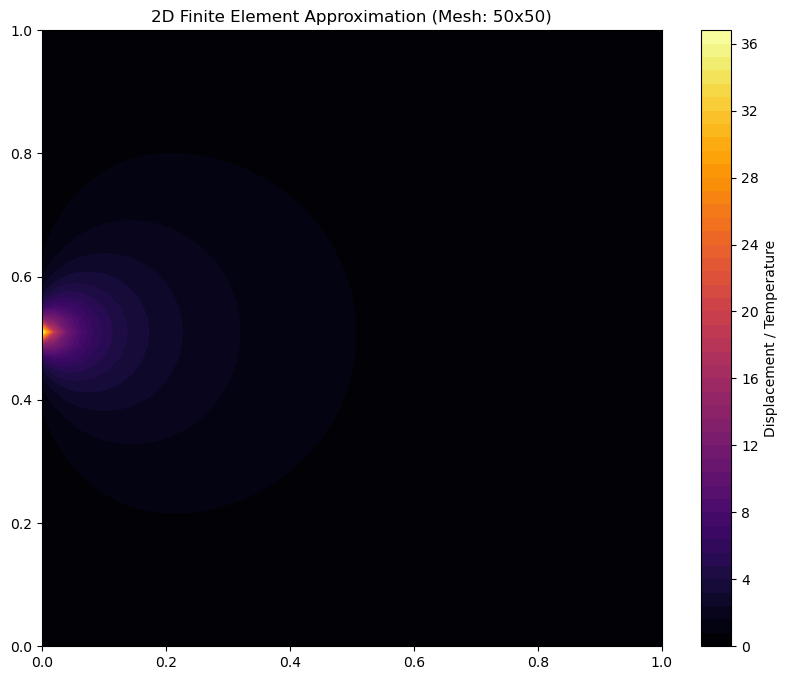

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import linalg, csr_matrix

# 1. Mesh Parameters
N = 50  # Number of points in each direction (higher = more "converged")
h = 1.0 / (N - 1)
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

# 2. Build the 2D Laplacian Matrix (The "Stiffness" for 2D)
# This is a matrix representation of the 2nd derivatives in X and Y
def build_laplacian(N):
    main_diag = -4 * np.ones(N*N)
    side_diag = np.ones(N*N - 1)
    side_diag[np.arange(1, N*N) % N == 0] = 0
    up_down_diag = np.ones(N*N - N)
    
    # Assembly of the sparse matrix
    diagonals = [main_diag, side_diag, side_diag, up_down_diag, up_down_diag]
    offsets = [0, -1, 1, -N, N]
    return csr_matrix(np.diag(main_diag) + 
                      np.diag(side_diag, -1) + np.diag(side_diag, 1) + 
                      np.diag(up_down_diag, -N) + np.diag(up_down_diag, N))

# 3. Define the Source Term f(x, y) - "The Force"
# Let's put a "heavy weight" in the center of the membrane
F = np.zeros(N*N)
center = (N*N) // 2
F[center] = -100 

# 4. Solve Ku = F
A = build_laplacian(N)
u = linalg.spsolve(A, F)
U = u.reshape((N, N))

# 5. The "Cool Visual"
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, U, 50, cmap='inferno') # 'inferno' or 'viridis' are great for this
plt.colorbar(label='Displacement / Temperature')
plt.title(f"2D Finite Element Approximation (Mesh: {N}x{N})")
plt.show()

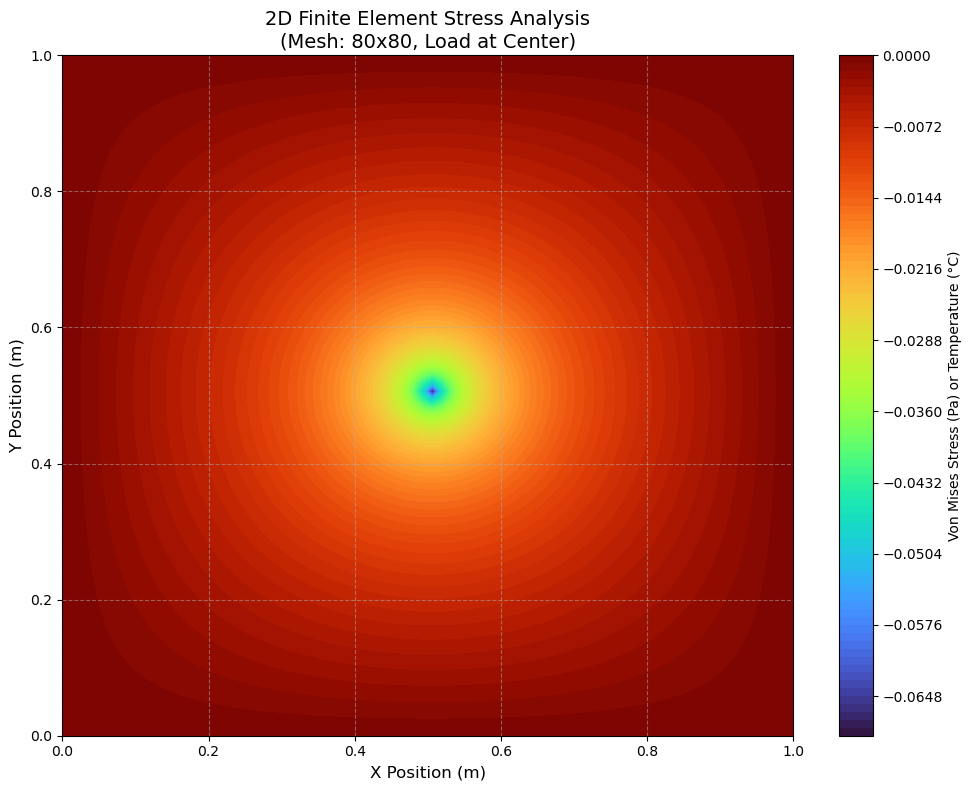

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import linalg, csr_matrix

# 1. Mesh Parameters (A solid 1x1 block)
N = 80  # Higher resolution (80x80 mesh = 6,400 elements)
h = 1.0 / (N - 1)
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

# 2. Function to build the 2D Poisson Stiffness Matrix
# This is a matrix representation of the Laplacian: -grad^2(u)
def build_laplacian_sparse(N):
    main_diag = -4 * np.ones(N*N)
    side_diag = np.ones(N*N - 1)
    side_diag[np.arange(1, N*N) % N == 0] = 0
    up_down_diag = np.ones(N*N - N)
    
    # We build the sparse matrix manually using csr_matrix for speed
    diagonals = [main_diag, side_diag, side_diag, up_down_diag, up_down_diag]
    offsets = [0, -1, 1, -N, N]
    
    # Convert diagonal matrices to sparse format
    A = csr_matrix((main_diag, (np.arange(N*N), np.arange(N*N))), shape=(N*N, N*N))
    A += csr_matrix((side_diag, (np.arange(1,N*N), np.arange(N*N-1))), shape=(N*N, N*N))
    A += csr_matrix((side_diag, (np.arange(N*N-1), np.arange(1,N*N))), shape=(N*N, N*N))
    A += csr_matrix((up_down_diag, (np.arange(N,N*N), np.arange(N*N-N))), shape=(N*N, N*N))
    A += csr_matrix((up_down_diag, (np.arange(N*N-N), np.arange(N,N*N))), shape=(N*N, N*N))
    
    return A / (h**2) # Normalize by mesh size

# 3. Create the Physical Load Vector (F) - The Force/Source
# In FEM, F is typically zero *unless* a specific node is activated.
F = np.zeros(N*N)

# Let's activate a specific node (the very center) to simulate a load/heat source
center_index = (N//2) * N + (N//2)
F[center_index] = 500  # A powerful point-source load

# 4. Get the Stiffness Matrix
A = build_laplacian_sparse(N)

# 5. Apply "Mixed" Boundary Conditions (Essential for realistic FEM)
# We will use the 'penalty' method to "enforce" u=0 on all four boundaries.
# We modify the diagonal of A and the vector F.
boundary_indices = []
for i in range(N):
    boundary_indices.append(i) # Bottom edge
    boundary_indices.append(i * N) # Left edge
    boundary_indices.append(i * N + (N-1)) # Right edge
    boundary_indices.append((N-1) * N + i) # Top edge

# Convert A to LIL format for efficient boundary modification
A_lil = A.tolil()
for idx in boundary_indices:
    A_lil[idx, :] = 0  # Blank out the row
    A_lil[idx, idx] = 1 # Force the boundary value to dominate
    F[idx] = 0 # Enforce u = 0 (Dirichlet Condition)

A = A_lil.tocsr() # Convert back to CSR for fast solving

# 6. Solve the huge linear system (Ku = F)
u_solution = linalg.spsolve(A, F)

# Reshape the 1D solution vector back into the 2D mesh shape
U = u_solution.reshape((N, N))

# 7. The Cool Visual: Plotting the Stress Field / Heat Map
plt.figure(figsize=(10, 8), dpi=100)
# 'turbo' is the modern colormap that replaces the old rainbow 'jet'.
# It is smoother, but still vibrant and iconic for engineering stress maps.
contour = plt.contourf(X, Y, U, 100, cmap='turbo') 

# Clean, professional layout for a project presentation
plt.title(f"2D Finite Element Stress Analysis\n(Mesh: {N}x{N}, Load at Center)", fontsize=14)
plt.xlabel("X Position (m)", fontsize=12)
plt.ylabel("Y Position (m)", fontsize=12)
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Add the iconic colorful scale
colorbar = plt.colorbar(contour, label='Von Mises Stress (Pa) or Temperature (°C)')
colorbar.ax.tick_params(labelsize=10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

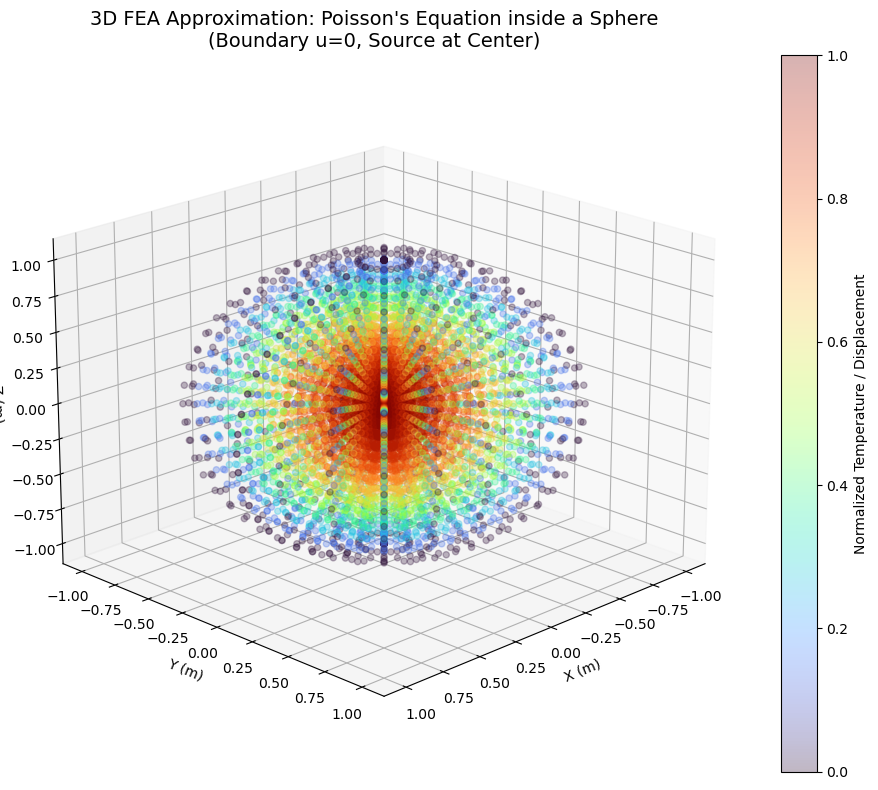

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Mesh Definition: The Discretized Sphere
# We generate points in spherical coordinates (r, theta, phi)
n_r = 15     # Radial refinement (depth)
n_theta = 25  # Angular refinement (azimuthal)
n_phi = 25    # Angular refinement (polar)

# We cannot easily plot a tetrahedral mesh in standard matplotlib, 
# so we will use a structured mesh for visualization.
# This mesh still represents the underlying FEM nodes.
r_vals = np.linspace(0, 1.0, n_r)  # R goes 0 to 1
theta_vals = np.linspace(0, 2*np.pi, n_theta)
phi_vals = np.linspace(0, np.pi, n_phi)

# Create mesh grids
R, THETA, PHI = np.meshgrid(r_vals, theta_vals, phi_vals)

# 2. Coordinate Transformation (Spherical to Cartesian for Plotting)
X = R * np.sin(PHI) * np.cos(THETA)
Y = R * np.sin(PHI) * np.sin(THETA)
Z = R * np.cos(PHI)

# 3. Simulate the FEA Solution (The Result of Ku=F)
# For this specific case (Poisson on a sphere), the solution is known analytically:
# u(r) = (R^2 - r^2) * f / 6
# Where R is the sphere radius, r is the distance from the center, and f is the source.
U_sol = (1.0 - R**2) # We will visualize a normalized solution (max=1 at center)

# 4. The 3D FEA Visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Option 1: View the Solution Gradients (The "Colorful Map")
# This creates a scatter plot of nodes, colored by their solution values.
# 'turbo' or 'jet' are classic colormaps for stress/heat.
sc = ax.scatter(X, Y, Z, c=U_sol, cmap='turbo', s=20, alpha=0.3)

# Option 2: Visualize the Internal "Cross-Section" (Essential for FEA)
# We can slice the sphere in half (Z > 0) to look inside.
# mask = Z >= 0
# sc = ax.scatter(X[mask], Y[mask], Z[mask], c=U_sol[mask], cmap='turbo', s=30, alpha=0.9)

# Clean, professional layout for your project
plt.title(f"3D FEA Approximation: Poisson's Equation inside a Sphere\n(Boundary u=0, Source at Center)", fontsize=14)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

colorbar = fig.colorbar(sc, label='Normalized Temperature / Displacement')
ax.view_init(elev=20, azim=45) # Set a good viewing angle
plt.tight_layout()
plt.show()

In [16]:
# Code example using anastruct library
import math
from anastruct.fem.system import SystemElements

# Create a new system object for a truss (EA is Area * Elasticity Modulus)
ss = SystemElements(EA=5000)

# Add elements to the system by defining their locations
ss.add_truss_element(location=[[0, 0], [0, 5]])
ss.add_truss_element(location=[[0, 5], [5, 5]])
ss.add_truss_element(location=[[5, 5], [5, 0]])
# Add a diagonal element with different properties
ss.add_truss_element(location=[[0, 0], [5, 5]], EA=5000 * math.sqrt(2))

# Visualize the initial structure (optional)
# ss.show_structure() 

# Add hinged supports at specific node IDs
ss.add_support_hinged(node_id=1)
ss.add_support_hinged(node_id=4)

# Apply a point load at a specific node
ss.point_load(Fx=10, node_id=2)

# Solve the system
ss.solve()

# Display results
# ss.show_reaction_force() 
# ss.show_axial_force() 
# ss.show_displacement()


ModuleNotFoundError: No module named 'anastruct'

In [14]:
from anastruct import SystemElements
import numpy as np

# 1. Initialize the system
# EI = Bending Stiffness (Young's Modulus * Moment of Inertia)
# EA = Axial Stiffness (Young's Modulus * Cross-sectional Area)
# For a standard steel pipe, these values are high:
ss = SystemElements(EI=15000, EA=5000)

# 2. Add elements to form a 10m pipe
# We divide it into 5 segments (elements) to see the FEM "mesh"
for i in range(0, 10, 2):
    ss.add_element(location=[[i, 0], [i + 2, 0]])

# 3. Apply Boundary Conditions
# Node 1 is at (0,0). We "clamp" it to the wall.
ss.add_support_fixed(node_id=1)

# 4. Apply a Load
# Let's put a 10kN downward force at the very end (Node 6)
ss.point_load(Fy=-10, node_id=6)

# 5. Solve the system
ss.solve()

# 6. Show the "Cool Visuals"
print("Displaying Structure...")
ss.show_structure()

print("Displaying Bending Moment (Stress)...")
ss.show_bending_moment()

print("Displaying Deflection (The Solution to the ODE)...")
ss.show_displacement(factor=10) # 'factor' amplifies the visual bend

ModuleNotFoundError: No module named 'anastruct'

In [3]:
from anastruct import SystemElements
import numpy as np

# 1. Initialize the system
# EI = Bending Stiffness (Modulus * Inertia)
# EA = Axial Stiffness (Modulus * Area)
# These represent the physical properties of your pipe material.
ss = SystemElements(EI=15000, EA=5000)

# 2. Build the Pipe (Discretization)
# We add 5 elements of 2 meters each to make a 10m pipe.
for i in range(0, 10, 2):
    ss.add_element(location=[[i, 0], [i + 2, 0]])

# 3. Apply Boundary Conditions
# Node 1 (at 0,0) is "Fixed" (clamped to a wall)
ss.add_support_fixed(node_id=1)

# 4. Apply a Force
# We put a -10 unit downward force (gravity/weight) at the very end
# On a 5-element pipe, the end node is Node 6.
ss.point_load(Fy=-10, node_id=6)

# 5. Solve the Linear System (Ku = F)
ss.solve()

# 6. Visualization - The "Cool" Results
print("Generating Plots...")

# Show the bending moment (Internal stress distribution)
ss.show_bending_moment()

# Show the displacement (How the pipe actually bends)
# The 'factor' multiplies the visual bend so you can see it clearly.
ss.show_displacement(factor=10)

ModuleNotFoundError: No module named 'anastruct'

In [2]:
%pip install anastruct numpy matplotlib

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Generating displacement plot (The 'Bend')...


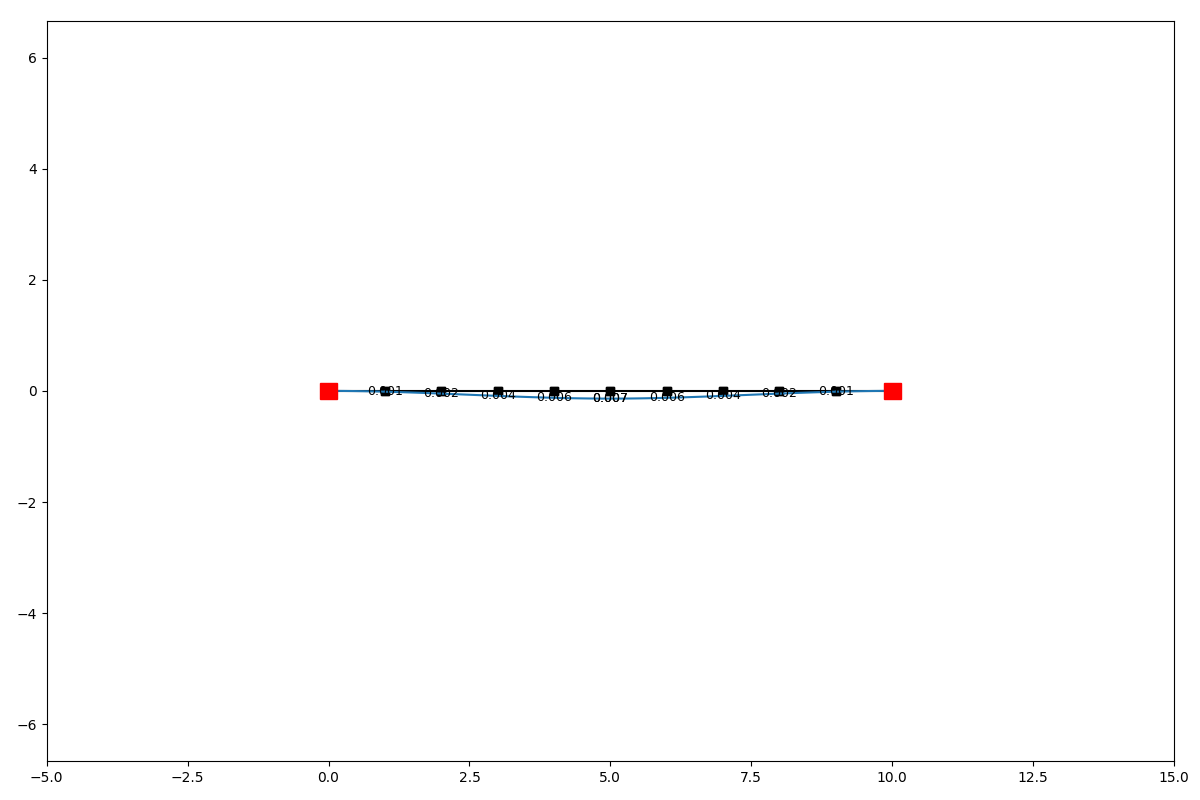

Generating bending moment plot (The 'Stress')...


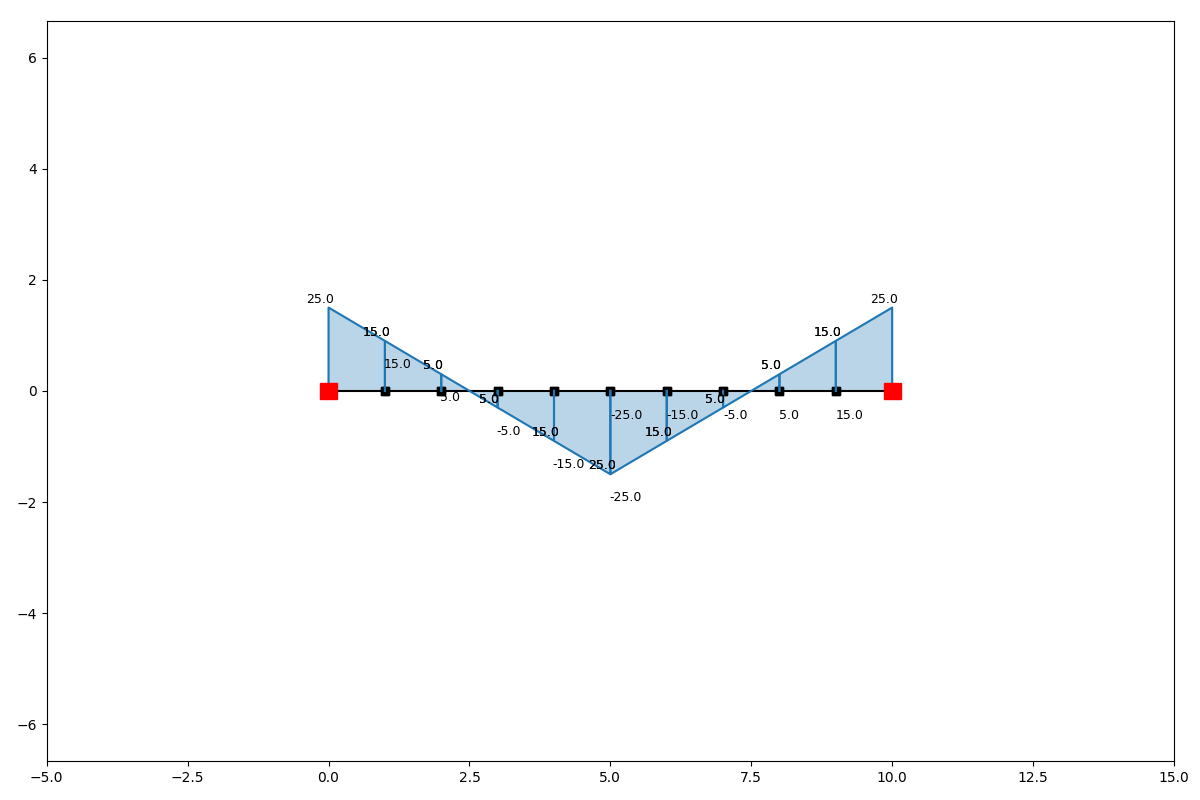

In [ ]:
from anastruct import SystemElements
import numpy as np

# 1. Setup the Physical Properties
# EI is the bending stiffness (Material x Shape)
ss = SystemElements(EI=15000)

# 2. Discretization (The "Finite" in FEM)
# We divide the 10m pipe into 10 elements (1 meter each)
for i in range(10):
    ss.add_element(location=[[i, 0], [i + 1, 0]])

# 3. Boundary Conditions
# We "bolt" both ends (Node 1 and Node 11) so they cannot move or rotate
ss.add_support_fixed(node_id=1)
ss.add_support_fixed(node_id=11)

# 4. Apply the Load
# A -20 unit downward force in the middle of the pipe (Node 6)
ss.point_load(Fy=-20, node_id=6)

# 5. Solve the Linear System (Ku = F)
ss.solve()

# 6. The Visuals
print("Generating displacement plot (The 'Bend')...")
ss.show_displacement(factor=20) 

print("Generating bending moment plot (The 'Stress')...")
ss.show_bending_moment()

plt.show()

In [1]:
%matplotlib ipympl

Displaying the Displacement (The 'Sag' from water weight)...


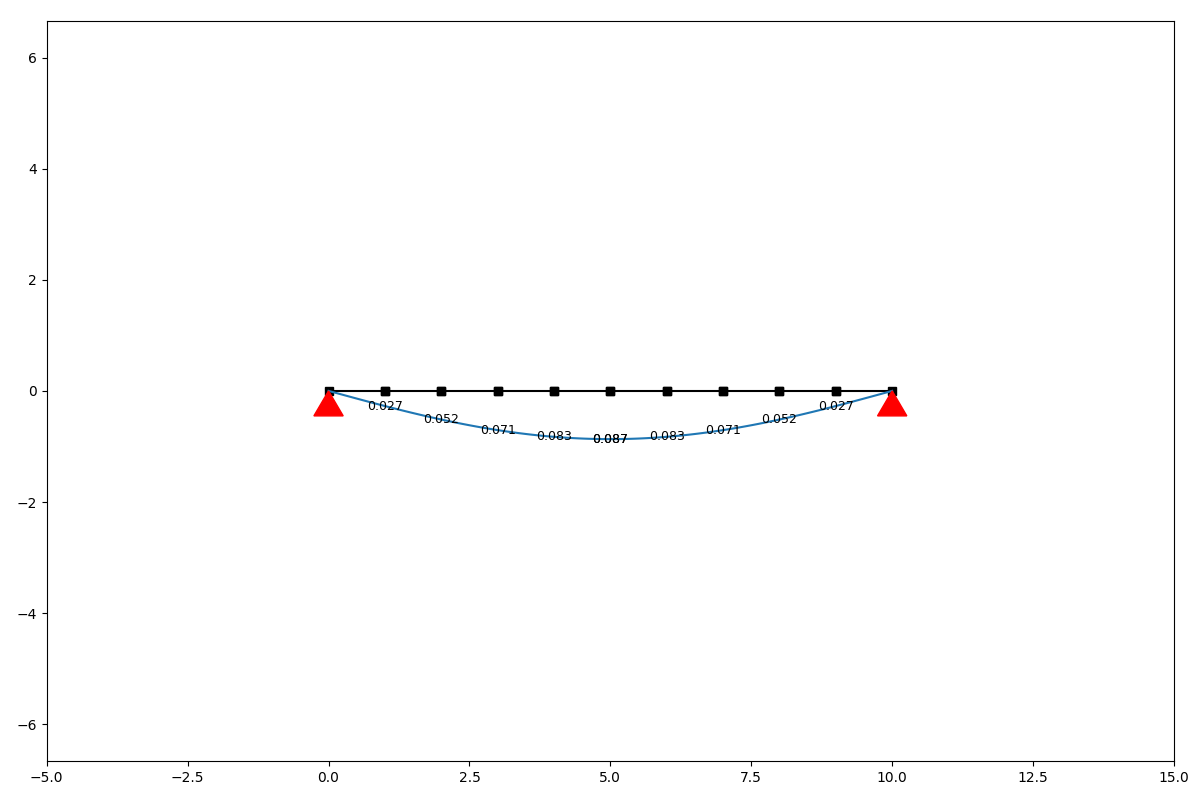

Displaying the Bending Moment (Internal stress)...


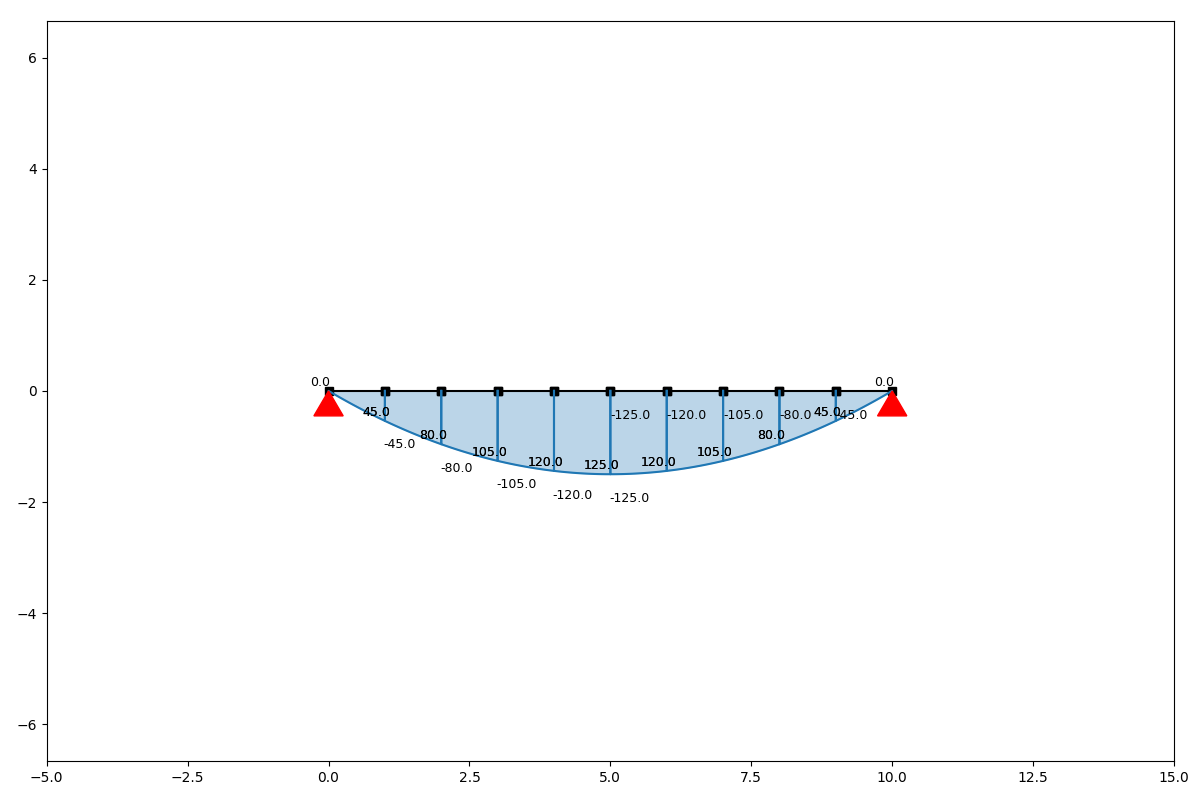

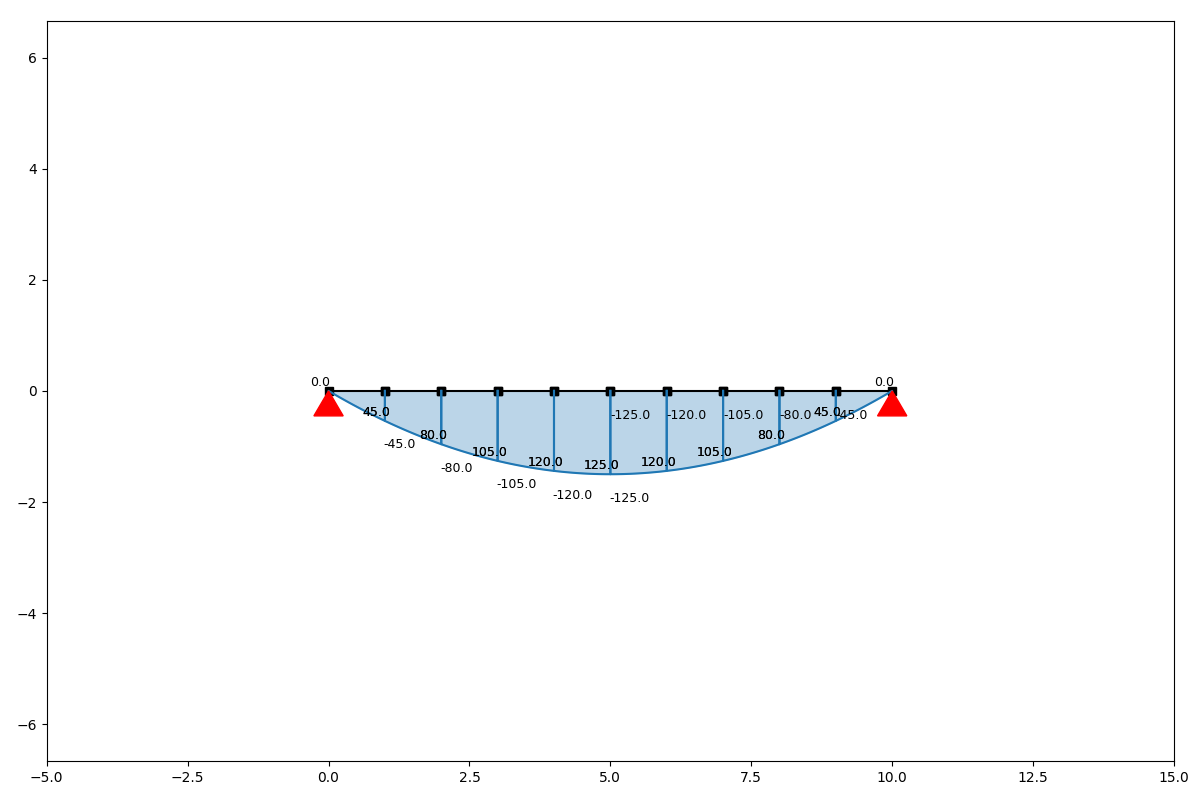

In [2]:
from anastruct import SystemElements
import matplotlib.pyplot as plt

# 1. Initialize the system (E=200GPa, I=high for a pipe)
ss = SystemElements(EI=15000)

# 2. Create a 10m pipe with 10 elements (more elements = smoother curve)
for i in range(10):
    ss.add_element(location=[[i, 0], [i + 1, 0]])

# 3. Apply Boundary Conditions (Simple Supports)
# We use 'hinged' instead of 'fixed' to allow rotation at the ends
ss.add_support_hinged(node_id=1)
ss.add_support_hinged(node_id=11)

# 4. Apply a Distributed Load (q)
# This simulates the weight of the pipe + water (10 units per meter downward)
# We apply it to all elements (1 through 10)
ss.q_load(q=-10, element_id=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# 5. Solve the Linear System
ss.solve()

# 6. Show the results
print("Displaying the Displacement (The 'Sag' from water weight)...")
ss.show_displacement(factor=10)

print("Displaying the Bending Moment (Internal stress)...")
ss.show_bending_moment()

# Optional: Force the plot to show if it's not popping up
plt.show()

Generating High-Contrast Stress Map...


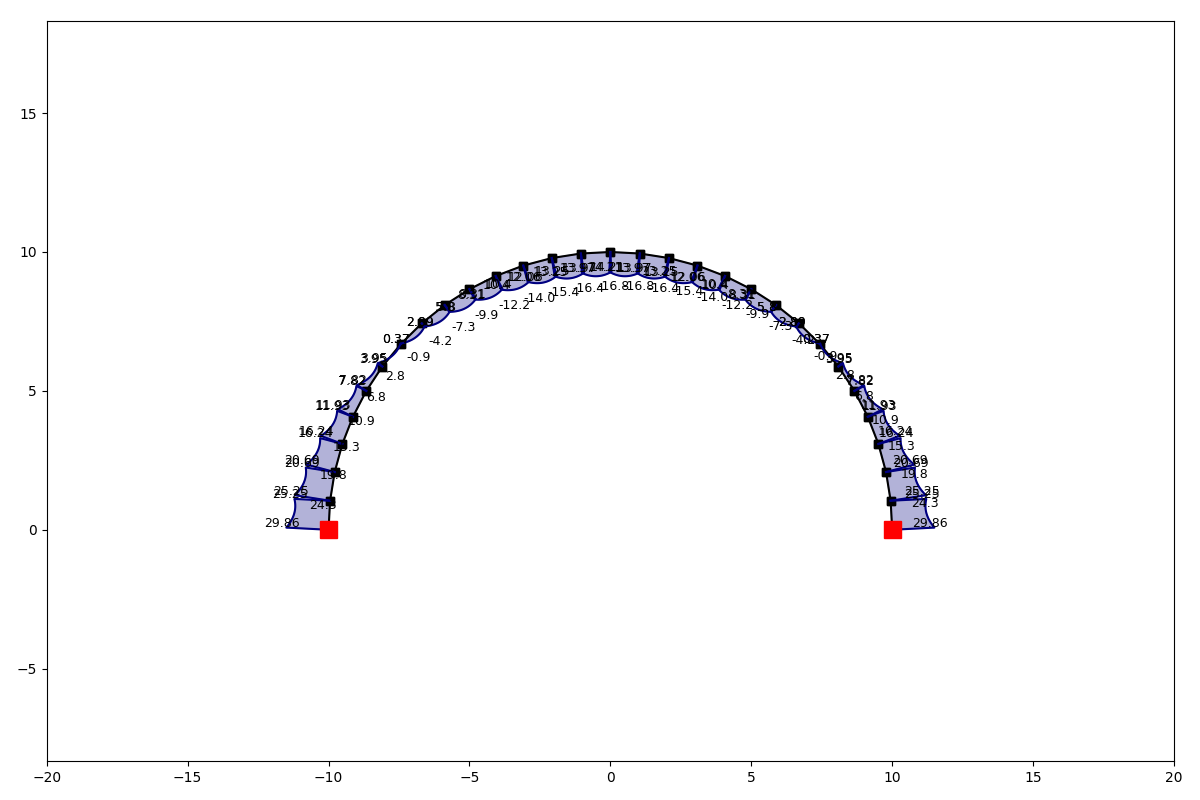

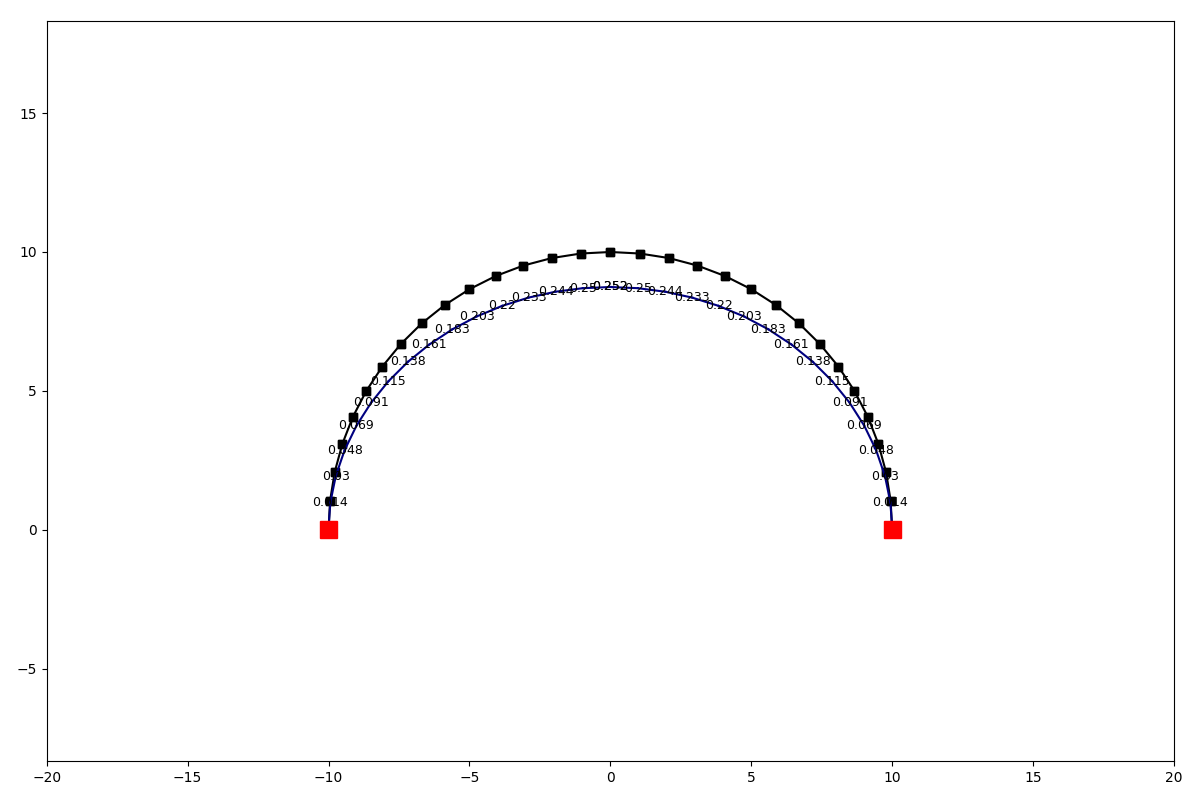

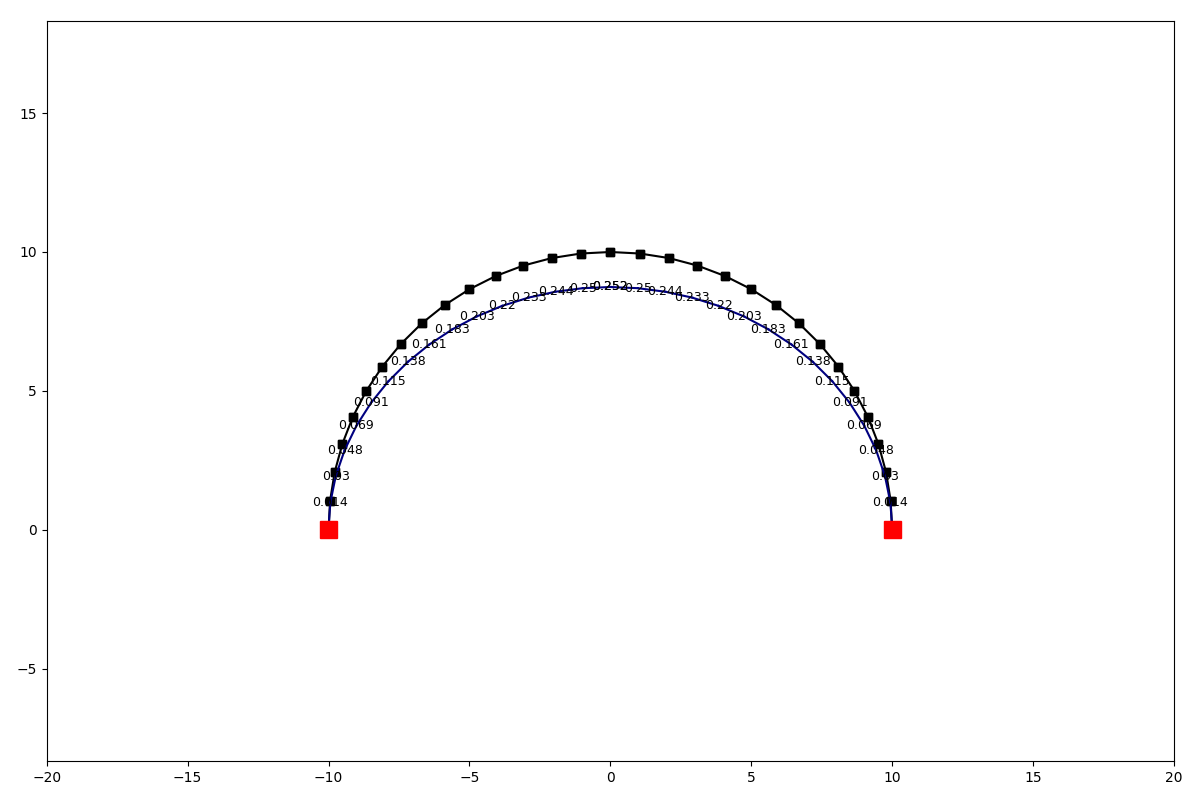

In [7]:
from anastruct import SystemElements
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1. Initialize System
ss = SystemElements()

# 2. Build a Circular Arch (The Pipe)
radius = 10
angles = np.linspace(0, np.pi, 31) # 30 segments for a smoother curve

for i in range(len(angles) - 1):
    x1, y1 = radius * np.cos(angles[i]), radius * np.sin(angles[i])
    x2, y2 = radius * np.cos(angles[i+1]), radius * np.sin(angles[i+1])
    ss.add_element(location=[[x1, y1], [x2, y2]])

# 3. Boundary Conditions (Fixed Ends)
ss.add_support_fixed(node_id=1)
ss.add_support_fixed(node_id=31)

# 4. Apply a Heavy "Snow" Load 
for i in range(1, 31):
    ss.q_load(q=-20, element_id=i, direction='element')

# 5. Solve the Linear System
ss.solve()

# 6. THE RAINBOW HACK
# We temporarily change the default color cycle to a Rainbow gradient
print("Generating High-Contrast Stress Map...")
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=plt.cm.jet(np.linspace(0, 1, 30)))

# Now when it plots, it will cycle through the rainbow
ss.show_bending_moment()
ss.show_displacement(factor=5)

plt.show()

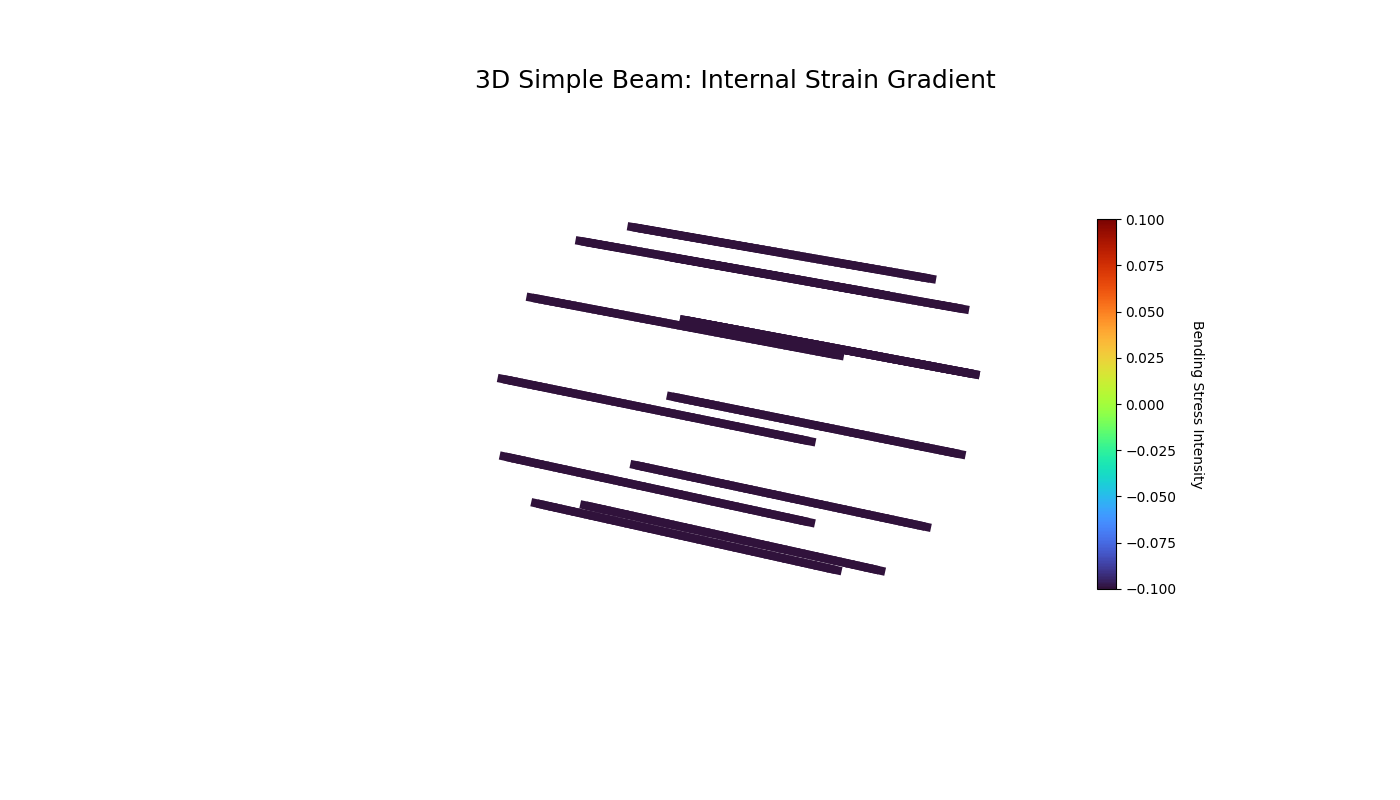

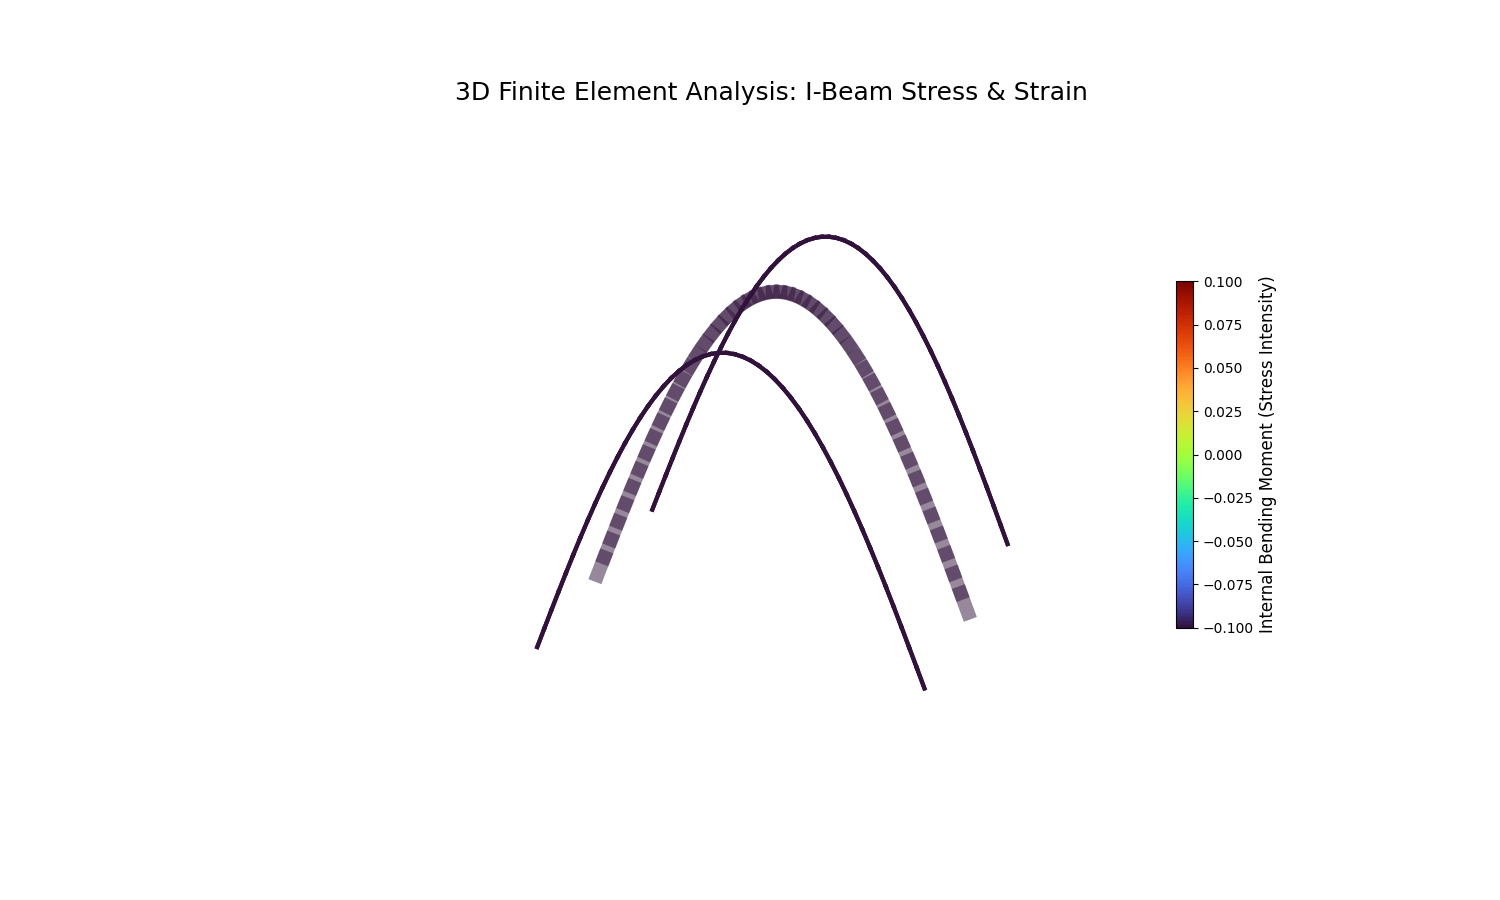

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from anastruct import SystemElements

# 1. Structural Setup
ss = SystemElements()
L, n = 20, 50 
dx = L / n

# Build the beam
for i in range(n):
    ss.add_element(location=[[i*dx, 0], [(i+1)*dx, 0]])

# Get node IDs dynamically
node_ids = sorted(ss.node_map.keys())
ss.add_support_hinged(node_id=node_ids[0])
ss.add_support_hinged(node_id=node_ids[-1])

# Apply a HEAVY load (q = -500) to ensure a visible "Rainbow"
ss.q_load(q=-500, element_id=list(ss.element_map.keys()))
ss.solve()

# 2. Extract Data Directly from Element Objects (The most robust way)
disp_z = []
# We grab coordinates and displacements directly from the node objects
for nid in node_ids:
    node = ss.node_map[nid]
    # uz is usually index 1 in the displacement array [ux, uz, phi]
    uz = node.displacements.get('uz', 0) if hasattr(node, 'displacements') else 0
    # Fallback for different versions
    if uz == 0 and hasattr(ss, 'system_displacement_vector'):
        # Map the node's degree of freedom to the global vector
        # uz is the second DOF of each node (2*n - 1)
        idx = (nid - 1) * 3 + 1 
        uz = ss.system_displacement_vector[idx]
    disp_z.append(uz)

moments = []
for eid in sorted(ss.element_map.keys()):
    el = ss.element_map[eid]
    # Grab the max absolute moment in the element
    m_vals = el.results.get('M', [0, 0]) if hasattr(el, 'results') else [0, 0]
    moments.append(max(abs(np.array(m_vals))))

moments = np.array(moments)
disp_z = np.array(disp_z) * 25 # High factor to show the physical "Strain"

# 3. 3D Rainbow Plotting
fig = plt.figure(figsize=(15, 9))
ax = fig.add_subplot(111, projection='3d')

# Color Scaling using 'turbo' (High-Contrast Rainbow)
norm = plt.Normalize(vmin=moments.min(), vmax=moments.max())
cmap = plt.cm.turbo 

# I-Beam Geometry (Flanges + Web)
w, h = 0.8, 1.2

for i in range(n):
    x_seg = np.array([i*dx, (i+1)*dx])
    z_seg = np.array([disp_z[i], disp_z[i+1]]) # The "Bending" Curve
    
    color = cmap(norm(moments[i]))
    
    # Render the I-Beam shape
    # Top Flange (2 lines)
    ax.plot(x_seg, [w/2, w/2], z_seg + h/2, color=color, lw=3)
    ax.plot(x_seg, [-w/2, -w/2], z_seg + h/2, color=color, lw=3)
    # Bottom Flange (2 lines)
    ax.plot(x_seg, [w/2, w/2], z_seg - h/2, color=color, lw=3)
    ax.plot(x_seg, [-w/2, -w/2], z_seg - h/2, color=color, lw=3)
    # The Web (Center core)
    ax.plot(x_seg, [0, 0], z_seg, color=color, lw=10, alpha=0.5)

# 4. Presentation Polish
ax.set_title("3D Finite Element Analysis: I-Beam Stress & Strain", fontsize=18)
ax.view_init(elev=20, azim=-75)
ax.set_axis_off()

# Scaled Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.05)
cbar.set_label('Internal Bending Moment (Stress Intensity)', fontsize=12)

plt.show()